## Model Training


In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import warnings

#### Import the CSV Data as Pandas DataFrame

In [2]:
df=pd.read_csv('Dataset/Crop_recommendation.csv')

In [3]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


#### Preparing X and Y variables

In [4]:
X = df.drop(columns=['label'],axis=1)

In [5]:
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [6]:
y=df['label']

In [7]:
y.head()

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object

In [8]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns


from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()


preprocessor = ColumnTransformer(
    [
        
         ("StandardScaler", numeric_transformer, num_features)      
    ]
)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [10]:
X = preprocessor.fit_transform(X)

In [11]:
X.shape

(2200, 7)

In [12]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((1760, 7), (440, 7))

#### Create an Evaluate Function to give all metrics after model Training

In [13]:
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return accuracy, precision, recall, f1

In [14]:
models = {
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "XGBClassifier": XGBClassifier(), 
    "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier()

}

model_list = []


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    
    acc_train, prec_train, rec_train, f1_train = evaluate_model(y_train, y_train_pred)
    acc_test, prec_test, rec_test, f1_test = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("Accuracy:", acc_train)
    print("Precision:", prec_train)
    print("Recall:", rec_train)
    print("F1 Score:", f1_train)

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("Accuracy:", acc_test)
    print("Precision:", prec_test)
    print("Recall:", rec_test)
    print("F1 Score:", f1_test)
    
    
    print('='*35)
    print('\n')

K-Neighbors Classifier
Model performance for Training set
Accuracy: 0.9863636363636363
Precision: 0.9870918920901163
Recall: 0.9863636363636363
F1 Score: 0.9863573444192507
----------------------------------
Model performance for Test set
Accuracy: 0.9568181818181818
Precision: 0.9628976143584398
Recall: 0.9568181818181818
F1 Score: 0.9567492608232794


Decision Tree
Model performance for Training set
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
----------------------------------
Model performance for Test set
Accuracy: 0.9863636363636363
Precision: 0.9868055555555556
Recall: 0.9863636363636363
F1 Score: 0.9863152866630287


Random Forest Classifier
Model performance for Training set
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
----------------------------------
Model performance for Test set
Accuracy: 0.9931818181818182
Precision: 0.9937348484848485
Recall: 0.9931818181818182
F1 Score: 0.9931754816901672


XGBClassifier
Model performance for Training set
Accuracy: 

d:\Major Project\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Major Project\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Gradient Boosting Classifier
Model performance for Training set
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
----------------------------------
Model performance for Test set
Accuracy: 0.9818181818181818
Precision: 0.9842712842712842
Recall: 0.9818181818181818
F1 Score: 0.9818514668069125




In [15]:
print(model_list)

['K-Neighbors Classifier', 'Decision Tree', 'Random Forest Classifier', 'XGBClassifier', 'CatBoosting Classifier', 'AdaBoost Classifier', 'Gradient Boosting Classifier']


## the Gradient Boosting Classifier performs best on this dataset 

### Gradient Boosting Classifier

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

score = accuracy_score(y_test, y_pred) * 100

print("Accuracy of the model is %.2f" % score)

Accuracy of the model is 95.68


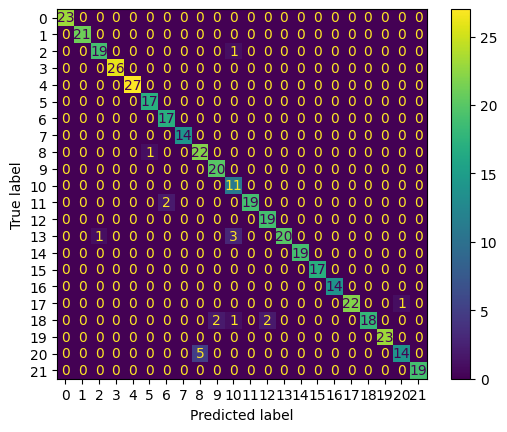

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = knn_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [18]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(20))

    Actual  Predicted
0       15         15
1       21         21
2       17         17
3       17         17
4        0          0
5       12         12
6        0          0
7       13         13
8       14         14
9       10         10
10       2          2
11       4          4
12      19         19
13       8          8
14       4          4
15      19         19
16       0          0
17      11          6
18      17         17
19      15         15


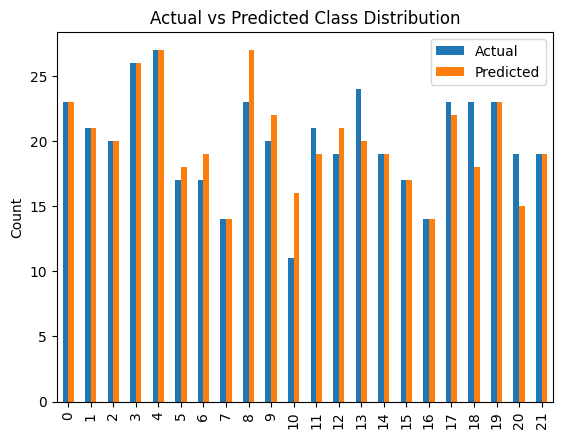

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

actual_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

df_plot = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': pred_counts
})

df_plot.plot(kind='bar')
plt.title('Actual vs Predicted Class Distribution')
plt.ylabel('Count')
plt.show()

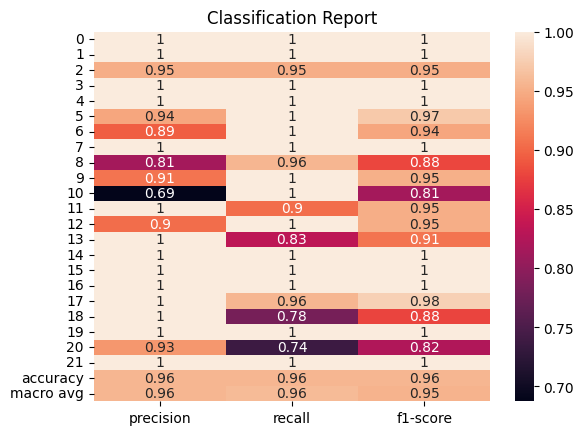

In [20]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

sns.heatmap(report_df.iloc[:-1, :-1], annot=True)
plt.title("Classification Report")
plt.show()